In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv ("retail_store_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_6867343,CUST_05,Furniture,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


In [5]:
print("Rows and Columns",df.shape)

Rows and Columns (12575, 11)


In [6]:
print(df.columns)

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')


In [7]:
print(df.dtypes)

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object


In [8]:
missing=df.isnull().sum()
print(missing)

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [9]:
duplicates=df.duplicated().sum
print("duplicate Records:",duplicates)

duplicate Records: <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
12570    False
12571    False
12572    False
12573    False
12574    False
Length: 12575, dtype: bool>


In [10]:
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_table

,Missing Count,Missing %
Transaction ID,0,0.00
Customer ID,0,0.00
Category,0,0.00
Item,1213,9.65
Price Per Unit,609,4.84
Quantity,604,4.80
Total Spent,604,4.80
Payment Method,0,0.00
Location,0,0.00
Transaction Date,0,0.00


In [11]:

mask = df["Total Spent"].isnull() & df["Price Per Unit"].notnull() & df["Quantity"].notnull()
df.loc[mask, "Total Spent"] = df.loc[mask, "Price Per Unit"] * df.loc[mask, "Quantity"]

In [12]:

mask = df["Price Per Unit"].isnull() & df["Total Spent"].notnull() & df["Quantity"].notnull() & (df["Quantity"] != 0)
df.loc[mask, "Price Per Unit"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Quantity"]

In [13]:

mask = df["Quantity"].isnull() & df["Total Spent"].notnull() & df["Price Per Unit"].notnull() & (df["Price Per Unit"] != 0)
df.loc[mask, "Quantity"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Price Per Unit"]

In [14]:

df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())

In [15]:

df["Item"] = df["Item"].fillna("Unknown")

In [16]:

df["Discount Applied"].value_counts(dropna=False)

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64

In [17]:
df["Discount Applied"] = df["Discount Applied"].fillna("Unknown")

In [18]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Removing Duplicate Records

In [19]:
duplicates_before = df.duplicated().sum()
duplicates_before

0

In [20]:
df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()
duplicates_after

0

In [21]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df["Transaction ID"] = df["Transaction ID"].astype(str)
df["Customer ID"] = df["Customer ID"].astype(str)
df["Price Per Unit"] = df["Price Per Unit"].astype(float)
df["Quantity"] = df["Quantity"].astype(int)
df["Total Spent"] = df["Total Spent"].astype(float)

df.dtypes

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                     int32
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object

In [22]:
df["Category"] = df["Category"].str.strip().str.title()
df["Item"] = df["Item"].str.strip().str.title()
df["Payment Method"] = df["Payment Method"].str.strip().str.title()
df["Location"] = df["Location"].str.strip().str.title()
df["Discount Applied"] = df["Discount Applied"].astype(str).str.strip().str.title()

In [23]:
df["Category"].unique(), df["Payment Method"].unique(), df["Location"].unique()

(array(['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
        'Furniture', 'Electric Household Essentials',
        'Computers And Electric Accessories'], dtype=object),
 array(['Digital Wallet', 'Credit Card', 'Cash'], dtype=object),
 array(['Online', 'In-Store'], dtype=object))

In [24]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total Spent"] < lower) | (df["Total Spent"] > upper)]
print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
print("Outliers detected:", outliers.shape[0])

Lower bound: -138.50, Upper bound: 377.50
Outliers detected: 157


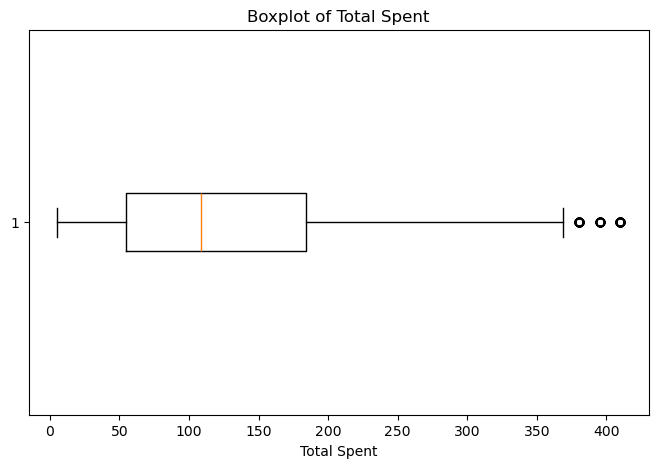

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Total Spent"], vert=False)
plt.title("Boxplot of Total Spent")
plt.xlabel("Total Spent")
plt.show()

In [26]:

df["Total Spent"] = np.clip(df["Total Spent"], lower, upper)

In [27]:
df["Total Spent Check"] = df["Price Per Unit"] * df["Quantity"]

In [28]:

df["Month"] = df["Transaction Date"].dt.month_name()
df["Day of Week"] = df["Transaction Date"].dt.day_name()

In [29]:

df["Spend Tier"] = np.where(df["Total Spent"] >= df["Total Spent"].median(), "High", "Low")

In [30]:
df[["Total Spent", "Month", "Day of Week", "Spend Tier"]].head()

,Total Spent,Month,Day of Week,Spend Tier
0,185.0,April,Monday,High
1,261.0,July,Sunday,High
2,43.0,October,Wednesday,Low
3,247.5,May,Saturday,High
4,87.5,October,Sunday,Low


In [31]:
scaler = MinMaxScaler()
df["Total Spent Normalized"] = scaler.fit_transform(df[["Total Spent"]])

df[["Total Spent", "Total Spent Normalized"]].head()

,Total Spent,Total Spent Normalized
0,185.0,0.483221
1,261.0,0.687248
2,43.0,0.102013
3,247.5,0.651007
4,87.5,0.221477


In [32]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Total Spent Check,Month,Day of Week,Spend Tier,Total Spent Normalized
0,TXN_6867343,CUST_09,Patisserie,Item_10_Pat,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,185.0,April,Monday,High,0.483221
1,TXN_3731986,CUST_22,Milk Products,Item_17_Milk,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,261.0,July,Sunday,High,0.687248
2,TXN_9303719,CUST_02,Butchers,Item_12_But,21.5,2,43.0,Credit Card,Online,2022-10-05,False,43.0,October,Wednesday,Low,0.102013
3,TXN_9458126,CUST_06,Beverages,Item_16_Bev,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown,247.5,May,Saturday,High,0.651007
4,TXN_4575373,CUST_05,Food,Item_6_Food,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,87.5,October,Sunday,Low,0.221477


In [33]:
df.isnull().sum()

Transaction ID            0
Customer ID               0
Category                  0
Item                      0
Price Per Unit            0
Quantity                  0
Total Spent               0
Payment Method            0
Location                  0
Transaction Date          0
Discount Applied          0
Total Spent Check         0
Month                     0
Day of Week               0
Spend Tier                0
Total Spent Normalized    0
dtype: int64

In [34]:
df.duplicated().sum()

0

In [35]:
df.dtypes

Transaction ID                    object
Customer ID                       object
Category                          object
Item                              object
Price Per Unit                   float64
Quantity                           int32
Total Spent                      float64
Payment Method                    object
Location                          object
Transaction Date          datetime64[ns]
Discount Applied                  object
Total Spent Check                float64
Month                             object
Day of Week                       object
Spend Tier                        object
Total Spent Normalized           float64
dtype: object

In [36]:
df.shape

(12575, 16)

In [37]:
df.to_csv("clean_sales_data.csv", index=False)
print("Clean dataset exported as clean_sales_data.csv")

Clean dataset exported as clean_sales_data.csv
